In [1]:
# Prepare input for GrowthSimulation.py
import numpy as np
import itertools
import csv
import pandas as pd
from tqdm import tqdm
import sys
sys.path.append('FitSeq2/src/')
import GrowthSimulation
import os
import time
import matplotlib.pyplot as plt
import pickle
import scipy.stats

In [2]:
dir_simulation = './fitseq_data'
N_trials = 3
N_reads_per_barcode = 100
lineages_num = int(100)

In [ ]:
for trial in tqdm(range(N_trials)):
    

    delta_t = 4
    t_seq = np.arange(0, delta_t*6, delta_t)

    # tmp_1 = {
    #     '0': t_seq, 
    #     # '1': 20*np.ones(np.shape(t_seq)), 
    #     # '2': 50*np.ones(np.shape(t_seq)), 
    #     # '3': 100*np.ones(np.shape(t_seq))}
    #     '1': 100*np.ones(np.shape(t_seq))}

    tmp_1 = N_reads_per_barcode * np.ones((len(t_seq),2))
    tmp_1[:,0] = t_seq

    np.savetxt(dir_simulation + '/' + 't_input_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv',tmp_1,delimiter=',')
        
            
    ####################
    # initial cell number distribution
    # np.random.seed(10)
    param_a = 100
    param_b = 2.5
    mean_value = param_a
    variance_value = 2 * param_a * param_b
    param_k = mean_value**2/variance_value
    param_theta = variance_value/mean_value
    n0 = np.random.gamma(param_k, param_theta, lineages_num).astype('int') 


    step_size = 0.001
    # np.random.seed(5)
    s = np.random.normal(0, 0.15, lineages_num)
    s_norm = s - np.dot(s, n0)/np.sum(n0) # normalize the fitness to relative fitness (relative to the mean fitness)
        
    s_lim_left, s_lim_right = -1, 1
    s_norm[s_norm < s_lim_left] = s_lim_left
    s_norm[s_norm > s_lim_right] = s_lim_right
        
    tmp_2 = {'0':s_norm, '1':n0}
    tmp = list(itertools.zip_longest(*list(tmp_2.values())))
    with open(dir_simulation + '/simu_input_fitness_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', 'w') as f:
        w = csv.writer(f)
        w.writerows(tmp)
    
    np.savetxt(dir_simulation + '/fitseq2_F_real_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', s_norm)

    # Prepare input for FitSeq2.py
    csv_input = pd.read_csv(dir_simulation + '/t_input_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', low_memory=False, header=None)
    t_seq = np.array(csv_input[0][~pd.isnull(csv_input[0])], dtype=float)

    csv_input = pd.read_csv(dir_simulation + '/simu_input_fitness_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', low_memory=False, header=None)
    n0_array = np.array(csv_input[1][~pd.isnull(csv_input[1])], dtype=float)
    cell_depth_seq = np.sum(n0_array) * np.ones(t_seq.shape) # total cell number at the bottleneck
        
    input_tmp = {'0':t_seq, '1':cell_depth_seq}
    tmp = list(itertools.zip_longest(*list(input_tmp.values())))
    with open(dir_simulation + '/fitseq2_input_time_points_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', 'w') as f:
        w = csv.writer(f)
        w.writerows(tmp)
    
    command = f'python3 FitSeq2/src/GrowthSimulation.py -t {dir_simulation}/t_input_Nlin{lineages_num}_trial{trial}.csv -s {dir_simulation}/simu_input_fitness_Nlin{lineages_num}_trial{trial}.csv -o {dir_simulation}/simu_output_Nlin{lineages_num}_trial{trial}'
    os.system(command)


    ## prepare freq_timeseries and t_seq for FitSeq2 input

    read_timeseries = np.loadtxt(dir_simulation + '/simu_output_Nlin' + str(lineages_num) + '_trial' + str(trial) + '_0_EvoSimulation_Read_Number.csv',delimiter=',')
    read_totals = np.sum(read_timeseries, axis=0)
    freq_timeseries = read_timeseries / read_totals

    np.savetxt(dir_simulation + '/fitseq2_freq_timeseries_Nlin' + str(lineages_num) + '_trial' + str(trial) + '.csv', freq_timeseries, delimiter=',')

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:01<00:00,  2.82it/s]


In [3]:
lineages_num

100

In [4]:
for lineages_num in [100]:
    my_runtimes = np.zeros((N_trials))
    for trial in range(N_trials):
        start = time.perf_counter()
        os.system('python3.11 fitness_estimation_fitseq.py --model \'fitseq2\' --Nlin ' + str(lineages_num) + ' --nlogrcond 10000 --trial ' + str(trial) + ' --dir \'fitseq_data\' \n')
        end = time.perf_counter()
        my_runtimes[trial] = end - start

        np.savetxt('fitseq_data/my_runtimes_Nlin' + str(lineages_num) + '.csv', my_runtimes,delimiter=',')

115.66112443027504
60120749652342.28
-390643068121.67737
    rare_cutoffs_log10  N_common_variants  pearson_values  spearman_values
0                -5.00              100.0        0.975101         0.983078
1                -4.75              100.0        0.975101         0.983078
2                -4.50              100.0        0.975101         0.983078
3                -4.25              100.0        0.975101         0.983078
4                -4.00              100.0        0.975101         0.983078
5                -3.75              100.0        0.975101         0.983078
6                -3.50              100.0        0.975101         0.983078
7                -3.25              100.0        0.975101         0.983078
8                -3.00              100.0        0.975101         0.983078
9                -2.75               97.0        0.974868         0.982669
10               -2.50               68.0        0.983667         0.985075
11               -2.25               38.0  

In [5]:
fitseq_runtimes = np.zeros((N_trials))

for lineages_num in [100, 250, 500, 1000, 10_000, 15_000]:
    for trial in range(N_trials):
        start = time.perf_counter()
        os.system(f'python3.11 FitSeq2/src/FitSeq2.py -i {dir_simulation}/simu_output_Nlin{lineages_num}_trial{trial}_0_EvoSimulation_Read_Number.csv -t {dir_simulation}/fitseq2_input_time_points_Nlin{lineages_num}_trial{trial}.csv -dt 4 -n 3 -o {dir_simulation}/output_Nlin{lineages_num}_trial{trial} -p 0 \n')
        end = time.perf_counter()
        fitseq_runtimes[trial] = end - start

        np.savetxt('fitseq_data/fitseq_runtimes_Nlin' + str(lineages_num) + '.csv', fitseq_runtimes,delimiter=',')

--- iteration 1 ...


  0%|          | 0/100 [00:00<?, ?it/s]

    computing time: 3.75321 seconds
--- iteration 2 ...


  3%|▎         | 3/100 [00:00<00:03, 24.39it/s]

299.4612602305448
    computing time: 4.03948 seconds
--- iteration 3 ...


...

    computing time: 552.55103 seconds
--- iteration 2 ...


100%|██████████| 15000/15000 [09:47<00:00, 25.55it/s]


78645.69983767011
    computing time: 593.30467 seconds
--- iteration 3 ...


100%|██████████| 15000/15000 [09:51<00:00, 25.38it/s]


7170.032510194433
    computing time: 597.41277 seconds
Total computing time: 1743.26873 seconds


In [4]:
Nlin_list = [100, 250, 500, 1000, 10_000, 15_000]
my_runtimes = np.zeros((N_trials, len(Nlin_list)))
fitseq_runtimes = np.zeros((N_trials, len(Nlin_list)))
for lineages_num_i in range(len(Nlin_list)):
    my_runtime_indiv = np.loadtxt(dir_simulation + '/my_runtimes_Nlin' + str(Nlin_list[lineages_num_i]) + '.csv',delimiter=',')
    my_runtimes[:,lineages_num_i] = my_runtime_indiv[:3]
    fitseq_runtime_indiv = np.loadtxt(dir_simulation + '/fitseq_runtimes_Nlin' + str(Nlin_list[lineages_num_i]) + '.csv',delimiter=',')
    fitseq_runtimes[:,lineages_num_i] = fitseq_runtime_indiv[:3]

In [5]:
runtime_array = np.outer(np.ones((N_trials)), np.array(Nlin_list))

[ 2.30214793 -6.33636117]
[ 1.57147429 -3.45609779]
[ 0.98930322 -0.89833707]


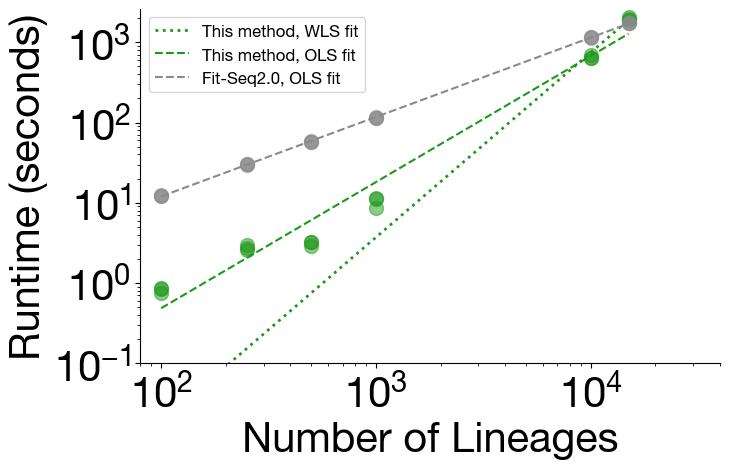

In [6]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 30}

plt.rc('font', **font)

fig, axs = plt.subplots(1,figsize=(8,5.4))
plt.tight_layout()


plt.plot(runtime_array,my_runtimes,color='#1C9918',marker='o',markersize=10,alpha=0.5,linestyle='')
## fit my runtimes
# WLS fit
x = np.log10(np.reshape(runtime_array, (N_trials*len(Nlin_list))))
y = np.log10(np.reshape(my_runtimes, (N_trials*len(Nlin_list))))
p = np.polyfit(x, y, deg=1,w=10**x)
print(p)
xrange = np.arange(np.log10(Nlin_list[0]),np.log10(Nlin_list[-1]),0.001)
yfit = p[0]*xrange + p[1]
plt.plot(10**xrange, 10**yfit,color='#1C9918',linestyle=':',label='This method, WLS fit',linewidth=2)

# OLS fit
p = np.polyfit(x, y, deg=1)
print(p)
yfit = p[0]*xrange + p[1]
plt.plot(10**xrange,10**yfit,color='#1C9918',linestyle='--',label='This method, OLS fit')

## fit fitseq runtimes
plt.plot(runtime_array,fitseq_runtimes,alpha=0.5,marker='o',markersize=10,color='#8A8A8A',linestyle='')
x = np.log10(np.reshape(runtime_array, (N_trials*len(Nlin_list))))
y = np.log10(np.reshape(fitseq_runtimes, (N_trials*len(Nlin_list))))
p = np.polyfit(x, y, deg=1)
print(p)
yfit = p[0]*xrange + p[1]
plt.plot(10**xrange,10**yfit,color='#8A8A8A',linestyle='--',label='Fit-Seq2.0, OLS fit')

plt.xscale('log')
plt.yscale('log')
axs.spines[['right', 'top']].set_visible(False)
plt.legend(loc='upper left',fontsize=12)


plt.xlim(80,40_000)
plt.ylim(0.1,2.6e3)
plt.xlabel('Number of Lineages')
plt.ylabel('Runtime (seconds)')

plt.tight_layout()
plt.savefig('paper_plots/runtimes.pdf')

In [7]:
my_pearson = np.zeros((N_trials, len(Nlin_list)))
fitseq_pearson = np.zeros((N_trials, len(Nlin_list)))
for lineages_num_i in range(len(Nlin_list)):
    for trial in range(N_trials):
        with open(dir_simulation + '/fitseq2_processed_Nlin' + str(Nlin_list[lineages_num_i]) + '_trial' + str(trial) + '.pkl','rb') as file:
            data = pickle.load(file)
            my_pearson[trial, lineages_num_i] = scipy.stats.pearsonr(data['F_est'],data['F_real'])[0]

        fitseq_df = pd.read_csv(dir_simulation + '/output_Nlin' + str(Nlin_list[lineages_num_i]) + '_trial' + str(trial) + '_FitSeq2_Result.csv')
        fitseq_pearson[trial, lineages_num_i] = scipy.stats.pearsonr(fitseq_df['Fitness_Per_Cycle'], data['F_real'])[0]

In [8]:
fitseq_pearson

array([[0.9791501 , 0.9775453 , 0.97579493, 0.97616259, 0.97595245,
        0.97682749],
       [0.98302656, 0.97999211, 0.97585319, 0.97632916, 0.97462313,
        0.97540034],
       [0.97348025, 0.98113693, 0.97635081, 0.97973834, 0.97575512,
        0.97662852]])

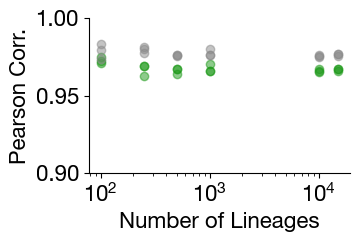

In [9]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 16}

plt.rc('font', **font)

fig, axs = plt.subplots(1,figsize=(4,2.7))
plt.tight_layout()


plt.plot(runtime_array,my_pearson,color='#1C9918',linestyle='',marker='o',markersize=6,alpha=0.5,label='This method')
plt.plot(runtime_array,fitseq_pearson,color='#8A8A8A',linestyle='',marker='o',markersize=6,alpha=0.5,label='Fit-Seq2.0')
## fit my runtimes

plt.xscale('log')
axs.spines[['right', 'top']].set_visible(False)

plt.xlabel('Number of Lineages')
plt.ylabel('Pearson Corr.')
plt.ylim(0.9,1.0)

plt.tight_layout()
plt.savefig('paper_plots/fitseq_pearson.pdf')

# main fig plots

In [10]:
freq_timeseries = np.loadtxt(dir_simulation + '/fitseq2_freq_timeseries_Nlin15000_trial0.csv',delimiter=',')

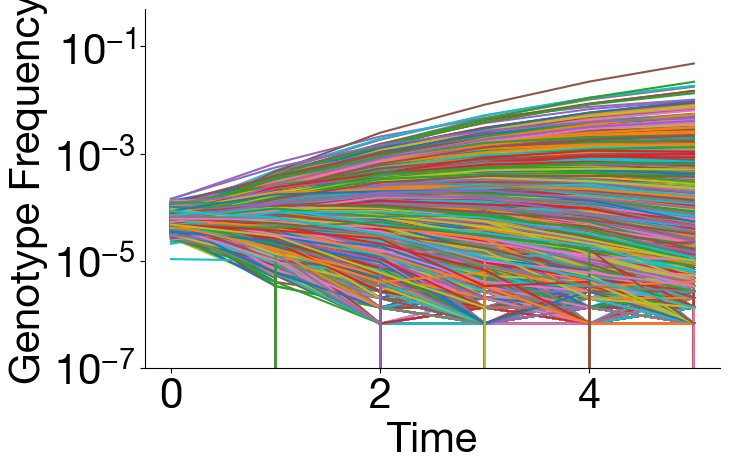

In [11]:
font = {'family' : 'Helvetica Neue',
        'weight' : 'normal',
        'size'   : 30}

plt.rc('font', **font)


fig, axs = plt.subplots(1,figsize=(8,5.4))
plt.tight_layout()

# [Panel A] first row
axs.plot(freq_timeseries.T)
# axs.set_xlim(0,freq_timeseries.T.shape[0])
axs.set_ylim(1e-7,5e-1)
axs.set_yscale('log')
# axs.set_ylim(0,1)
axs.set_xlabel('Time')
axs.set_ylabel('Genotype Frequency')
axs.spines[['right', 'top']].set_visible(False)
# axs[0].set_title('Wright-Fisher',fontsize=30)


plt.tight_layout()
plt.savefig('paper_plots/fitseq_sim_traj.png',dpi=300)

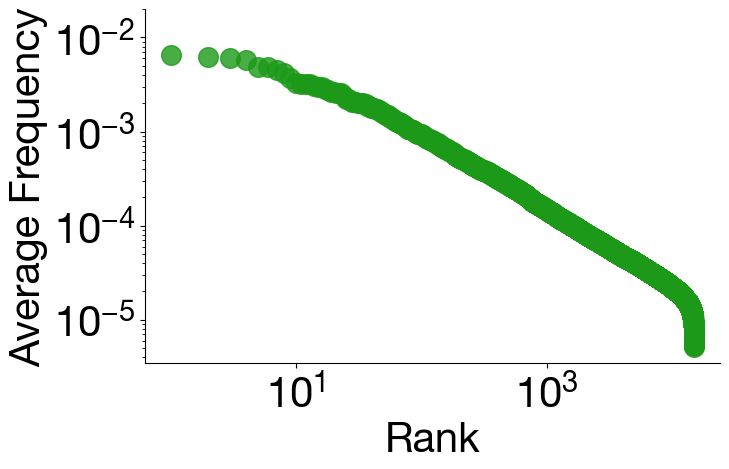

In [12]:
timeavg_freq = np.mean(freq_timeseries,axis=1)

fig, axs = plt.subplots(1,figsize=(8,5.4))
plt.tight_layout()

## [Panel B] second row (frequency-rank plots)

x = np.arange(len(timeavg_freq))
y = np.flip(np.sort(timeavg_freq))
axs.scatter(x,y,alpha=0.8,s=200,c='#1C9918')
axs.set_xlabel('Rank')
axs.set_ylabel('Average Frequency')
axs.set_xscale('log')
axs.set_yscale('log')
# axs[0].axhline(high_rare_cutoff,linestyle='--',color='grey', label='High Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].axhline(low_rare_cutoff,linestyle='-',color='black', label='Low Average Frequency Cutoff',linewidth=2,alpha=1)
# axs[0].legend(loc="upper right", title=False, fontsize=18).get_frame().set_alpha(0)
axs.spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/fitseq_sim_rank_freq.png',dpi=300)

In [13]:
with open(dir_simulation + '/fitseq2_processed_Nlin15000_trial0.pkl','rb') as file:
    data = pickle.load(file)
    F_est = data['F_est']
    F_real = data['F_real']

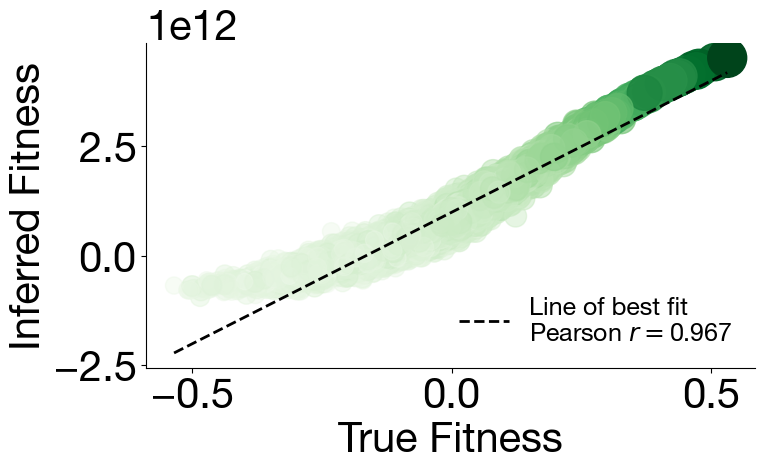

In [15]:
fig, axs = plt.subplots(1,figsize=(8,5.4))
plt.tight_layout()

rare_cutoff = 1e-1000

## [Panel C] third row (high Average Frequency Cutoffs)

x = data['F_real'][data['timeavg_freq'] > rare_cutoff]
y = data['F_est'][data['timeavg_freq'] > rare_cutoff]
# axs[0].scatter(x,y,100,alpha=0.8, c='#A41034')
alphas=(2+np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])))/np.max((2+np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff]))))
marker_sizes = 200*(1+np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])-np.min(np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])))-100
colors = 100+np.log10(data['timeavg_freq'][data['timeavg_freq'] > rare_cutoff])
axs.scatter(x,y,alpha=alphas,s=marker_sizes,c=colors,cmap='Greens')
# plt.xlim(3,5)
axs.set_xlabel('True Fitness')
axs.set_ylabel('Inferred Fitness')
# axs[0].set_ylim(-0.6,1)

pearson = scipy.stats.pearsonr(x, y)[0]

a, b = np.polyfit(x, y, 1)
xrange = np.linspace(np.min(x), np.max(x), 1000)
axs.plot(xrange, a*xrange+b, '--',color='black', label='Line of best fit\nPearson $r = $' + str(round(pearson,3)),linewidth=2,alpha=1)
axs.legend(loc="lower right", title=False, fontsize=18).get_frame().set_alpha(0)
axs.spines[['right', 'top']].set_visible(False)


plt.tight_layout()
plt.savefig('paper_plots/fitseq_sim_high_cutoff.png',dpi=300)